### 导入数据
计算mean,variance,std,median,min，max

### 生成数据

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取数据
path = "envelope.xlsx"
raw = pd.read_excel(path)

# 2. 去掉说明行
data = raw.iloc[1:151].reset_index(drop=True)

# 3. 位次列（第1~15位）
pos_cols = data.columns[2:17]

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) - 1

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

            mean  variance       std  median   min    max
pos_id                                                   
1       4.086467  4.988491  2.233493   4.060  0.40   7.99
2       4.410333  5.352752  2.313602   4.535  0.37   8.34
3       3.744867  5.469357  2.338666   3.325  0.36   8.27
4       4.085867  5.913806  2.431832   4.165  0.35   8.61
5       4.036933  5.972629  2.443896   4.065  0.34   9.34
6       4.162400  5.051206  2.247489   4.100  0.35   9.25
7       3.713467  6.263482  2.502695   3.305  0.30   9.66
8       3.886200  5.249626  2.291206   3.610  0.30   9.57
9       3.991533  5.987292  2.446894   3.930  0.28   9.99
10      3.951467  5.298245  2.301792   3.710  0.29  11.33
11      4.024533  6.487091  2.546977   3.780  0.36  11.80
12      4.003733  6.950203  2.636324   3.860  0.31  13.67
13      3.907733  9.358502  3.059167   3.160  0.22  18.07
14      4.098200  7.727628  2.779861   3.645  0.17  12.13
15      3.896267  9.696774  3.113964   3.105  0.02  16.30


#### 箱线图和散点图

C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 25250 (\N{CJK UNIFIED IDEOGRAPH-62A2}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\982155407.py:19: UserWarning: Glyph 33719 (\N{CJK UNIFI

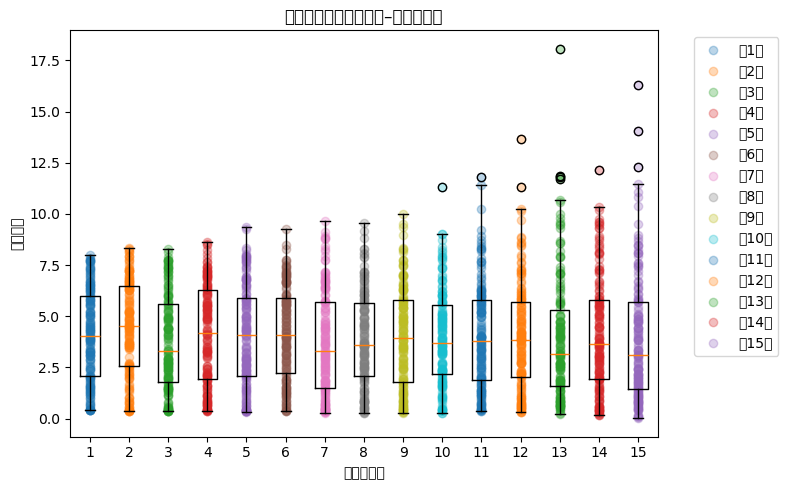

In [2]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, showfliers=True)

for pos in sorted(long_df["pos_id"].unique()):
    y = long_df[long_df["pos_id"] == pos]["amount"]
    x = np.full(len(y), pos)
    plt.scatter(x, y, alpha=0.3, label=f"第{pos}位")

plt.xlabel("抢红包位次")
plt.ylabel("获得金额")
plt.title("微信拼手气红包：位次–金额散点图")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）

C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  plt.tight_layout()
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_45072\1815219212.py:31: UserWarning: Glyph 25968 (\N{CJK

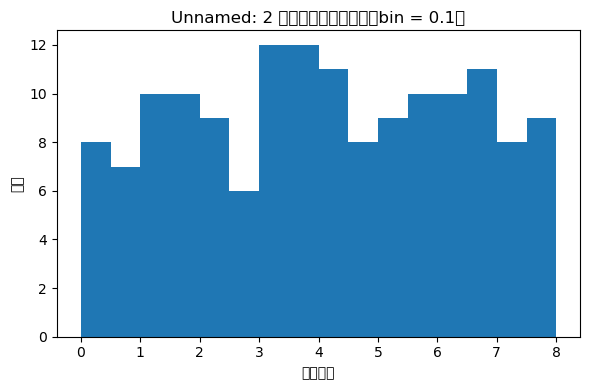

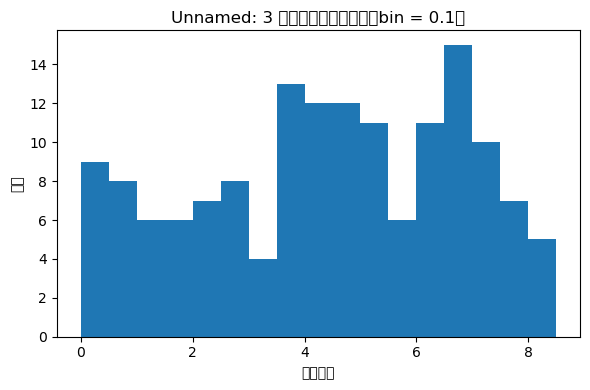

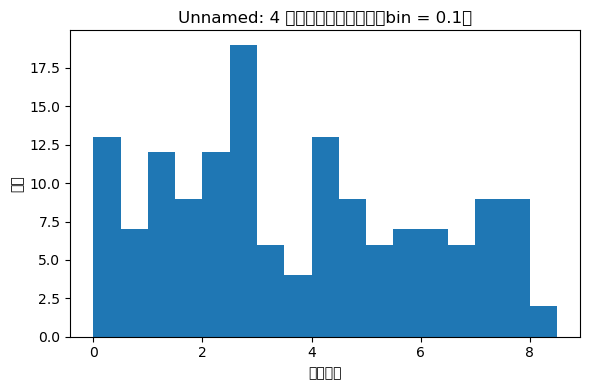

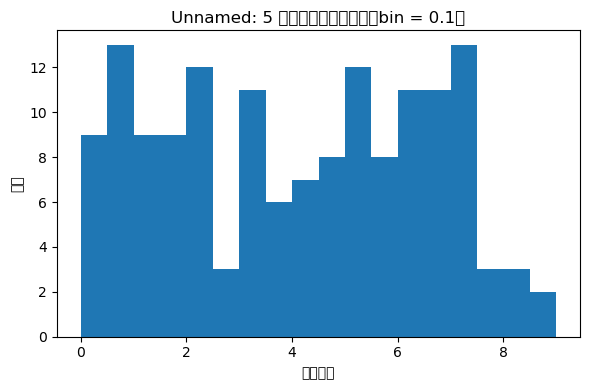

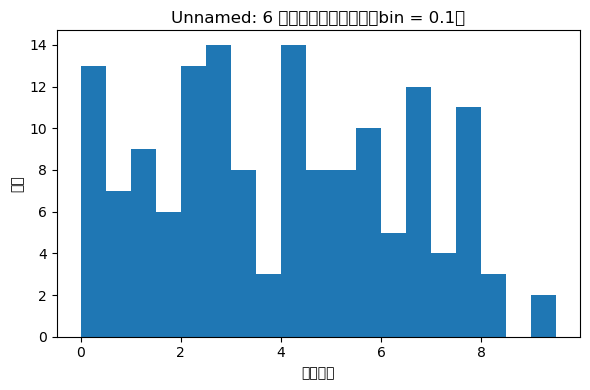

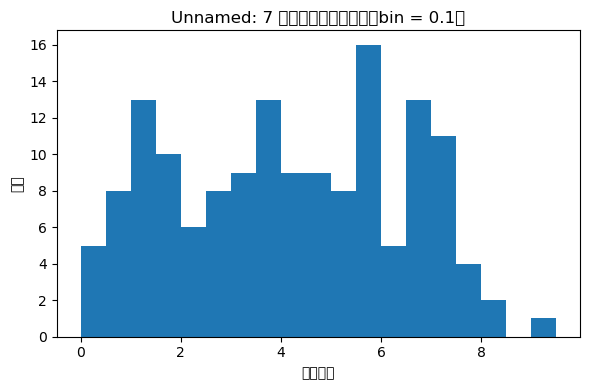

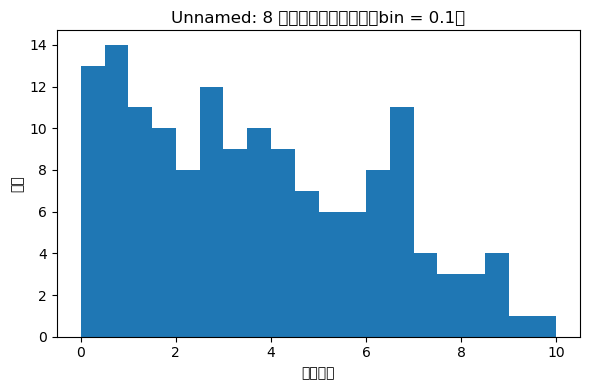

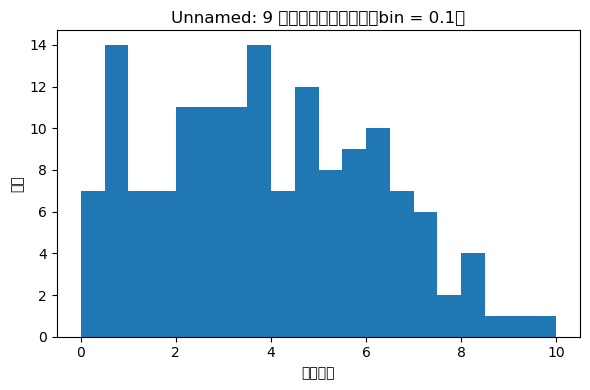

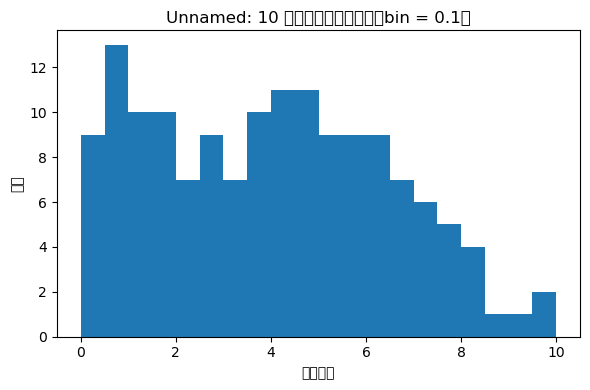

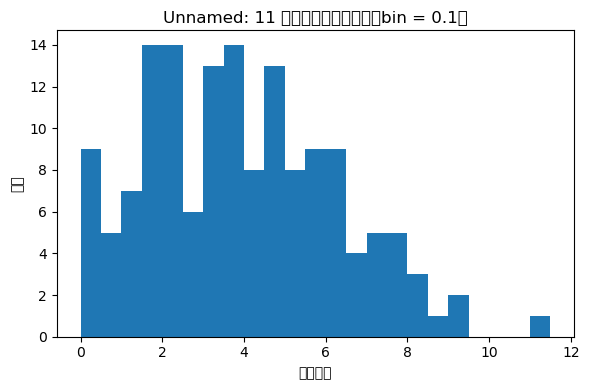

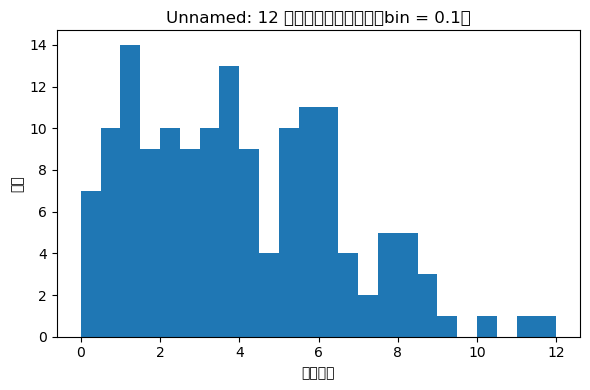

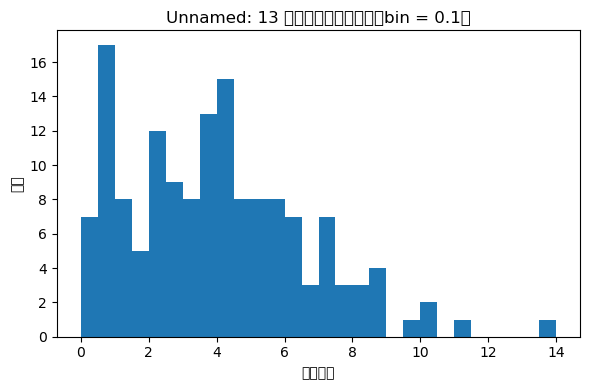

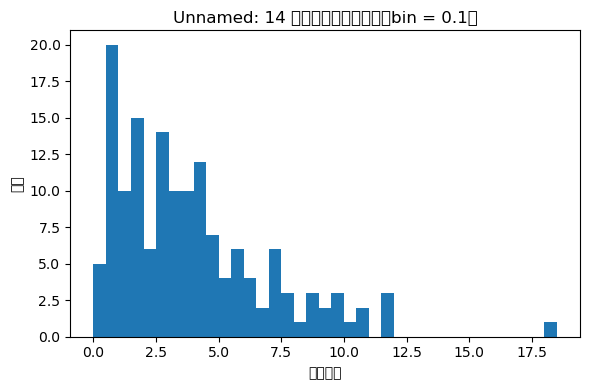

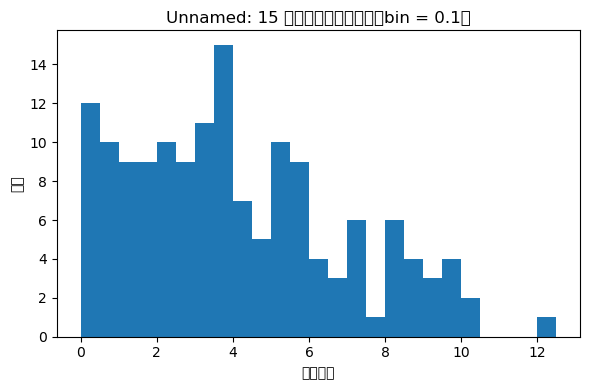

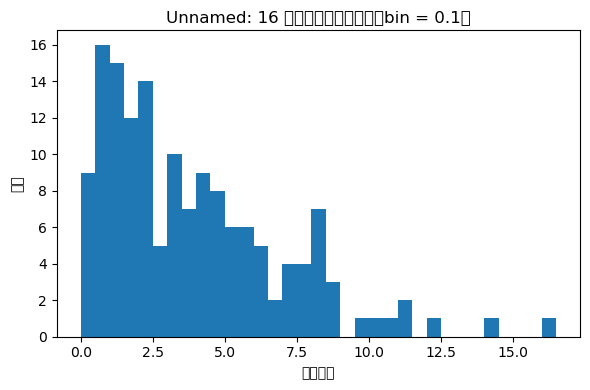

                  bin_left  bin_right  count
position   index                            
Unnamed: 2 0           0.0        0.5      8
           1           0.5        1.0      7
           2           1.0        1.5     10
           3           1.5        2.0     10
           4           2.0        2.5      9


In [4]:
# 4. 直方图区间宽度
bin_width = 0.5

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("红包金额")
    plt.ylabel("频数")
    plt.title(f"{col} 位次红包金额直方图（bin = 0.1）")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())